# Experiment: R(2) Opposite Parity Retention

Objective:
- Compare `R(2) F1'=7/2 F'=3` optical Bloch frequency scans with and without retaining the nearby excited-state opposite-parity manifold.
- Use `E = 200 V/cm` along Z, X-polarized light, 60 mW over a `2 cm x 2 cm` flat-top beam, and a 184 m/s molecular velocity.
- Start in `X, J=2, F1=5/2, F=2, mF=0`, i.e. the highest-F1 but not highest-F ground state.
- Add transverse Doppler averaging only by convolution of a fine zero-transverse-velocity scan.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as cst
import sympy as smp

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.lindblad.parameters import LindbladParameters
from centrex_tlf.lindblad.plan_static import prepare_lindblad_problem
from centrex_tlf.utils.rabi import (
    power_to_intensity_rectangular_beam,
    power_to_rabi_rectangular_beam,
)

plt.rcParams.update({"font.size": 14})

GAMMA = getattr(hamiltonian, "Γ")


## Configuration

For `R(2)`, the excited rotational level is `J'=3`. The ground parity is `P=(-1)^2=+`, so the addressed optical excited-state parity is `P'=-`; the retained opposite-parity excited levels have `P'=+`.


In [2]:
transition = transitions.R2_F1_7o2_F3

E_FIELD = np.array([0.0, 0.0, 200.0])  # V/cm, along Z
B_FIELD = np.array([0.0, 0.0, 1e-5])  # G, tiny quantization field
POWER = 60e-3  # W
BEAM_WX = 0.02  # m
BEAM_WY = 0.02  # m
VELOCITY = 184.0  # m/s
INTERACTION_LENGTH = 0.02  # m
T_END = INTERACTION_LENGTH / VELOCITY

DETUNING_SCAN_MHZ = np.linspace(-80.0, 80.0, 161)
SCAN_SAVEAT = np.linspace(0.0, T_END, 801)
SCAN_THREADS = None  # None lets the Rust backend choose; set an int to cap cores.

INITIAL_F1 = 5 / 2
INITIAL_F = 2
INITIAL_MF = 0

TRANSVERSE_VELOCITY_SIGMA = 1.4  # m/s
OPTICAL_FREQUENCY_HZ = 1.1e15
OPTICAL_WAVELENGTH_M = cst.c / OPTICAL_FREQUENCY_HZ
DOPPLER_SIGMA_MHZ = OPTICAL_FREQUENCY_HZ * TRANSVERSE_VELOCITY_SIGMA / cst.c / 1e6

INTENSITY = power_to_intensity_rectangular_beam(POWER, BEAM_WX, BEAM_WY)

config = {
    "transition": transition.name,
    "J_ground": transition.J_ground,
    "J_excited": transition.J_excited,
    "F1_excited": str(smp.Rational(transition.F1_excited).limit_denominator()),
    "F_excited": transition.F_excited,
    "addressed_excited_parity": "+" if transition.P_excited == 1 else "-",
    "opposite_excited_parity": "+" if -transition.P_excited == 1 else "-",
    "initial_state": f"X, J=2, F1=5/2, F=2, mF={INITIAL_MF}",
    "electric_field_V_per_cm": E_FIELD.tolist(),
    "polarization": "X",
    "power_mW": POWER * 1e3,
    "beam_area_cm2": (BEAM_WX * 100) * (BEAM_WY * 100),
    "intensity_mW_per_cm2": INTENSITY * 0.1,
    "velocity_m_per_s": VELOCITY,
    "interaction_time_us": T_END * 1e6,
    "detuning_scan_MHz": [float(DETUNING_SCAN_MHZ[0]), float(DETUNING_SCAN_MHZ[-1])],
    "detuning_scan_points": int(DETUNING_SCAN_MHZ.size),
    "doppler_sigma_MHz": float(DOPPLER_SIGMA_MHZ),
    "optical_wavelength_nm": float(OPTICAL_WAVELENGTH_M * 1e9),
}
config


{'transition': "R(2) F1'=7/2 F'=3",
 'J_ground': 2,
 'J_excited': 3,
 'F1_excited': '7/2',
 'F_excited': 3,
 'addressed_excited_parity': '-',
 'opposite_excited_parity': '+',
 'initial_state': 'X, J=2, F1=5/2, F=2, mF=0',
 'electric_field_V_per_cm': [0.0, 0.0, 200.0],
 'polarization': 'X',
 'power_mW': 60.0,
 'beam_area_cm2': 4.0,
 'intensity_mW_per_cm2': 15.0,
 'velocity_m_per_s': 184.0,
 'interaction_time_us': 108.69565217391305,
 'detuning_scan_MHz': [-80.0, 80.0],
 'detuning_scan_points': 161,
 'doppler_sigma_MHz': 5.136887066051542,
 'optical_wavelength_nm': 272.5385981818182}

## Nearby excited-state levels

This diagonalizes the full `J'=3` B manifold with both parities included and reports offsets relative to the X-driven same-parity `F1'=7/2, F'=3, mF=+/-1, P'=-` dressed pair. Frequencies are ordinary frequency offsets, not angular frequencies.


In [3]:
def _state_label(state: states.CoupledState) -> str:
    qn = state.largest
    f1 = smp.S(str(qn.F1), rational=True) if qn.F1 is not None else None
    parity = "+" if qn.P == 1 else "-"
    return f"J={qn.J}, F1={f1}, F={qn.F}, mF={qn.mF}, P={parity}"


def excited_level_offsets() -> list[dict[str, float | str | int]]:
    selector = states.QuantumSelector(
        electronic=states.ElectronicState.B,
        J=transition.J_excited,
        P=[transition.P_excited, -transition.P_excited],
    )
    approx_states = list(states.generate_coupled_states_B(selector))
    reduced = hamiltonian.generate_reduced_B_hamiltonian(
        approx_states,
        E=E_FIELD,
        B=B_FIELD,
        Jmin=transition.J_excited,
        Jmax=transition.J_excited + 2,
    )

    reference_indices = [
        i
        for i, state in enumerate(reduced.QN_basis)
        if state.largest.F1 == transition.F1_excited
        and state.largest.F == transition.F_excited
        and abs(state.largest.mF) == 1
        and state.largest.P == transition.P_excited
    ]
    if len(reference_indices) != 2:
        raise ValueError(f"Expected two mF=+/-1 reference states, got {reference_indices}")
    ref_energy = float(np.mean([np.real(reduced.H[idx, idx]) for idx in reference_indices]))

    rows = []
    for i, state in enumerate(reduced.QN_basis):
        qn = state.largest
        delta_mhz = (float(np.real(reduced.H[i, i])) - ref_energy) / (2 * np.pi * 1e6)
        rows.append(
            {
                "state": _state_label(state),
                "F1": str(smp.S(str(qn.F1), rational=True)),
                "F": int(qn.F),
                "mF": int(qn.mF),
                "parity": "+" if qn.P == 1 else "-",
                "delta_MHz": delta_mhz,
                "abs_delta_MHz": abs(delta_mhz),
            }
        )
    return sorted(rows, key=lambda row: row["abs_delta_MHz"])


level_offsets = excited_level_offsets()
nearby_counts = {
    f"within_{window}_MHz": sum(row["abs_delta_MHz"] <= window for row in level_offsets)
    for window in [5, 10, 20, 50, 100, 200]
}
f3_rows = [
    row
    for row in level_offsets
    if row["F1"] == str(smp.Rational(transition.F1_excited).limit_denominator())
    and row["F"] == transition.F_excited
]
for row in f3_rows:
    print(f"{row['delta_MHz']:12.6f} MHz  {row['state']}")
nearby_counts


    0.000001 MHz  J=3, F1=7/2, F=3, mF=-1, P=-
   -0.000001 MHz  J=3, F1=7/2, F=3, mF=1, P=-
   12.026306 MHz  J=3, F1=7/2, F=3, mF=0, P=-
  -14.214154 MHz  J=3, F1=7/2, F=3, mF=-2, P=-
  -14.214157 MHz  J=3, F1=7/2, F=3, mF=2, P=-
   17.019996 MHz  J=3, F1=7/2, F=3, mF=0, P=+
  -28.514876 MHz  J=3, F1=7/2, F=3, mF=-3, P=-
  -28.514881 MHz  J=3, F1=7/2, F=3, mF=3, P=-
   29.031699 MHz  J=3, F1=7/2, F=3, mF=1, P=+
   29.031701 MHz  J=3, F1=7/2, F=3, mF=-1, P=+
   43.202108 MHz  J=3, F1=7/2, F=3, mF=2, P=+
   43.202111 MHz  J=3, F1=7/2, F=3, mF=-2, P=+
   57.430124 MHz  J=3, F1=7/2, F=3, mF=3, P=+
   57.430129 MHz  J=3, F1=7/2, F=3, mF=-3, P=+


C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [24, 25, 36, 37, 38, 39, 54, 55]. Overlaps: [0.4908904035370138, 0.49068535899076277, 0.49089040347091345, 0.49068535903278154, 0.492017513739754, 0.4919882163394565, 0.49201751371476454, 0.4919882163148293]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(


{'within_5_MHz': 2,
 'within_10_MHz': 2,
 'within_20_MHz': 6,
 'within_50_MHz': 12,
 'within_100_MHz': 14,
 'within_200_MHz': 24}

With zero detuning defined by the X-driven `P'=-, mF=+/-1` pair, the nearby `F'=3` ladder includes the same-parity `mF=0, +/-2, +/-3` levels and the opposite-parity `mF=0, +/-1, +/-2, +/-3` levels. The next `F'=4` block remains outside this `+/-80 MHz` scan, and the nearest `F1'=5/2` block is several GHz away, so the scan below focuses on the `F'=3` manifold.


## Build OBE systems

The default system keeps the addressed `F'=3, P'=-` excited ladder. The opt-in retained system keeps that ladder plus the `F'=3, P'=+` opposite-parity ladder after the electric-field mixing calculation.


In [4]:
ground_main = 1 * next(
    iter(
        states.generate_coupled_states_X(
            states.QuantumSelector(
                electronic=states.ElectronicState.X,
                J=transition.J_ground,
                F1=INITIAL_F1,
                F=INITIAL_F,
                mF=INITIAL_MF,
                P=transition.P_ground,
            )
        )
    )
)
excited_main = 1 * next(
    iter(
        states.generate_coupled_states_B(
            states.QuantumSelector(
                electronic=states.ElectronicState.B,
                J=transition.J_excited,
                F1=transition.F1_excited,
                F=transition.F_excited,
                mF=1,
                P=transition.P_excited,
            )
        )
    )
)

transition_selectors = couplings.generate_transition_selectors(
    transitions=[transition],
    polarizations=[[couplings.polarization_X]],
    ground_mains=[ground_main],
    excited_mains=[excited_main],
)

systems = {
    "default": lindblad.generate_OBE_system_transitions(
        [transition],
        transition_selectors,
        E=E_FIELD,
        B=B_FIELD,
        method="matrix",
    ),
    "retained_B_opposite_parity": lindblad.generate_OBE_system_transitions(
        [transition],
        transition_selectors,
        E=E_FIELD,
        B=B_FIELD,
        retain_opposite_parity_levels=True,
        method="matrix",
    ),
}
DISPLAY_LABELS = {
    "default": "default",
    "retained_B_opposite_parity": "retained P'=+",
}


def included_f3_states(system: lindblad.OBESystem) -> list[str]:
    return [
        _state_label(state)
        for state in system.excited
        if state.largest.J == transition.J_excited
        and state.largest.F1 == transition.F1_excited
        and state.largest.F == transition.F_excited
    ]


for name, system in systems.items():
    retained = included_f3_states(system)
    print(
        f"{DISPLAY_LABELS[name]}: {len(system.QN)} total levels, {len(retained)} retained F'=3 levels"
    )
    for state in retained:
        print("  ", state)


C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 6]. Overlaps: [0.49174457879912414, 0.49174457871440175]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 10]. Overlaps: [0.43344884338308637, 0.4334488177466614]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.49174457879912414, 0.49163644217435554, 0.49174457871440175, 0.49163644220088737]. The approximate states may not be well-represented in the eigenstate basis.
  ind

default: 147 total levels, 7 retained F'=3 levels
   J=3, F1=7/2, F=3, mF=-3, P=-
   J=3, F1=7/2, F=3, mF=-2, P=-
   J=3, F1=7/2, F=3, mF=-1, P=-
   J=3, F1=7/2, F=3, mF=0, P=-
   J=3, F1=7/2, F=3, mF=1, P=-
   J=3, F1=7/2, F=3, mF=2, P=-
   J=3, F1=7/2, F=3, mF=3, P=-
retained P'=+: 154 total levels, 14 retained F'=3 levels
   J=3, F1=7/2, F=3, mF=-3, P=-
   J=3, F1=7/2, F=3, mF=-3, P=+
   J=3, F1=7/2, F=3, mF=-2, P=-
   J=3, F1=7/2, F=3, mF=-2, P=+
   J=3, F1=7/2, F=3, mF=-1, P=-
   J=3, F1=7/2, F=3, mF=-1, P=+
   J=3, F1=7/2, F=3, mF=0, P=-
   J=3, F1=7/2, F=3, mF=0, P=+
   J=3, F1=7/2, F=3, mF=1, P=-
   J=3, F1=7/2, F=3, mF=1, P=+
   J=3, F1=7/2, F=3, mF=2, P=-
   J=3, F1=7/2, F=3, mF=2, P=+
   J=3, F1=7/2, F=3, mF=3, P=-
   J=3, F1=7/2, F=3, mF=3, P=+


## Scan helpers

The Hamiltonian convention uses the symbolic Rabi rate as the main transition's Rabi rate. The photon count is the Rust `photon_integral` output, `integral Gamma P_excited(t) dt`, over the 2 cm beam crossing. `parallel=True` uses the Rust parallel grid path; set `SCAN_THREADS` above to an integer to cap the core count.


In [5]:
def parameter_values(system: lindblad.OBESystem) -> tuple[LindbladParameters, float]:
    main_coupling = abs(system.couplings[0].main_coupling)
    rabi_rate = power_to_rabi_rectangular_beam(
        POWER,
        main_coupling,
        BEAM_WX,
        BEAM_WY,
    )

    values = {str(symbol): 0.0 for symbol in system.H_symbolic.free_symbols}
    for symbol in system.coupling_symbols:
        values[str(symbol)] = rabi_rate
    for symbol_group in system.polarization_symbols:
        symbols = symbol_group if isinstance(symbol_group, (list, tuple)) else [symbol_group]
        for symbol in symbols:
            values[str(symbol)] = 1.0

    params = LindbladParameters()
    for name, value in values.items():
        params.real(name, float(value))
    return params, rabi_rate


def initial_state_index(system: lindblad.OBESystem) -> int:
    candidates = []
    for idx, state in enumerate(system.QN):
        qn = state.largest
        if (
            qn.electronic_state == states.ElectronicState.X
            and qn.J == transition.J_ground
            and qn.F1 == INITIAL_F1
            and qn.F == INITIAL_F
            and qn.mF == INITIAL_MF
        ):
            candidates.append(idx)
    if not candidates:
        raise ValueError("Could not find the requested X-state initial level.")
    return min(candidates, key=lambda idx: float(np.real(system.H_int[idx, idx])))


def initial_density_matrix(system: lindblad.OBESystem) -> np.ndarray:
    rho0 = np.zeros((len(system.QN), len(system.QN)), dtype=np.complex128)
    idx = initial_state_index(system)
    rho0[idx, idx] = 1.0
    return rho0


def index_sets(system: lindblad.OBESystem) -> dict[str, list[int]]:
    ground = []
    excited = []
    addressed_f3 = []
    opposite_f3 = []
    initial = []
    for idx, state in enumerate(system.QN):
        qn = state.largest
        if qn.electronic_state == states.ElectronicState.X:
            ground.append(idx)
            if (
                qn.J == transition.J_ground
                and qn.F1 == INITIAL_F1
                and qn.F == INITIAL_F
                and qn.mF == INITIAL_MF
            ):
                initial.append(idx)
        elif qn.electronic_state == states.ElectronicState.B:
            excited.append(idx)
            is_f3 = (
                qn.J == transition.J_excited
                and qn.F1 == transition.F1_excited
                and qn.F == transition.F_excited
            )
            if is_f3 and qn.P == transition.P_excited:
                addressed_f3.append(idx)
            if is_f3 and qn.P == -transition.P_excited:
                opposite_f3.append(idx)
    return {
        "ground": ground,
        "excited": excited,
        "addressed_f3": addressed_f3,
        "opposite_f3": opposite_f3,
        "initial": initial,
    }


def f3_line_groups(max_abs_mhz: float = 80.0) -> list[dict[str, object]]:
    groups: dict[tuple[str, int], list[dict[str, float | str | int]]] = {}
    for row in f3_rows:
        if row["abs_delta_MHz"] > max_abs_mhz:
            continue
        key = (str(row["parity"]), abs(int(row["mF"])))
        groups.setdefault(key, []).append(row)

    line_groups = []
    for (parity, abs_mf), rows in sorted(groups.items(), key=lambda item: (item[0][0], item[0][1])):
        detuning_mhz = float(np.mean([float(row["delta_MHz"]) for row in rows]))
        mfs = sorted(int(row["mF"]) for row in rows)
        if abs_mf == 0:
            mf_label = "mF=0"
        else:
            mf_label = f"mF=+/-{abs_mf}"
        directly_driven = abs_mf == 1
        if directly_driven and parity == ("+" if transition.P_excited == 1 else "-"):
            role = "X-driven addressed parity"
        elif directly_driven:
            role = "X-driven opposite parity"
        else:
            role = "nearby, not driven from initial mF=0 by ideal X"
        line_groups.append(
            {
                "detuning_MHz": detuning_mhz,
                "label": f"P'={parity}, {mf_label}: {role}",
                "parity": parity,
                "abs_mF": abs_mf,
                "mF_values": mfs,
                "directly_driven": directly_driven,
            }
        )
    return sorted(line_groups, key=lambda group: float(group["detuning_MHz"]))


def add_f3_level_markers(ax, max_abs_mhz: float = 80.0) -> None:
    groups = f3_line_groups(max_abs_mhz=max_abs_mhz)
    annotation_y = [0.96, 0.82, 0.68, 0.54]
    for i, group in enumerate(groups):
        directly_driven = bool(group["directly_driven"])
        parity = group["parity"]
        color = "C3" if parity == "+" else "C2"
        detuning_mhz = float(group["detuning_MHz"])
        abs_mf = int(group["abs_mF"])
        if abs_mf == 0:
            box_text = f"P'={parity}\nmF=0"
        else:
            box_text = f"P'={parity}\nmF=+/-{abs_mf}"
        ax.axvline(
            detuning_mhz,
            color=color,
            lw=2.2 if directly_driven else 1.6,
            ls="-" if directly_driven else "--",
            alpha=0.95 if directly_driven else 0.85,
            label="_nolegend_",
            zorder=1,
        )
        ax.text(
            detuning_mhz,
            annotation_y[i % len(annotation_y)],
            box_text,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            color=color,
            fontsize=10,
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": "white",
                "edgecolor": color,
                "alpha": 0.9,
            },
            zorder=3,
        )


def side_legend(ax: plt.Axes, *, fontsize: int = 11, ncols: int = 1) -> None:
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=True,
        fontsize=fontsize,
        ncols=ncols,
    )


def print_scan_timings(summary: dict[str, dict[str, object]], title: str) -> None:
    print(title)
    for name, row in summary.items():
        total_seconds = row.get("solver_total_seconds")
        label = DISPLAY_LABELS.get(name, name)
        if total_seconds is None:
            print(f"  {label}: solver time unavailable")
        else:
            print(f"  {label}: {float(total_seconds):.1f} s")


def photon_count_frequency_scan(
    system: lindblad.OBESystem,
    detuning_mhz: np.ndarray = DETUNING_SCAN_MHZ,
    threads: int | None = SCAN_THREADS,
) -> dict[str, object]:
    params, rabi_rate = parameter_values(system)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    excited_indices = index_sets(system)["excited"]
    photon_integral_weights = [(int(idx), float(GAMMA)) for idx in excited_indices]
    delta_symbol = getattr(transition_selectors[0], "δ")

    result = lindblad.grid_scan(
        prepared,
        initial_density_matrix(system),
        (0.0, T_END),
        scan={delta_symbol: 2 * np.pi * 1e6 * detuning_mhz},
        solver="dopri5",
        execution_mode="expanded_sparse",
        output="photon_integral",
        output_when="saveat",
        integral_weights=photon_integral_weights,
        saveat=SCAN_SAVEAT,
        dt=2e-9,
        reltol=1e-7,
        abstol=1e-9,
        parallel=True,
        threads=threads,
        collect_stats=True,
    )

    photons = result.values.reshape(detuning_mhz.size, -1)[:, 0]
    return {
        "detuning_MHz": detuning_mhz,
        "photons": photons,
        "rabi_rate": rabi_rate,
        "result": result,
    }


## Frequency scan without transverse Doppler averaging

This cell scans `-80..80 MHz` at the plotted detuning points. Both systems use the same initial density matrix and beam-derived Rabi rate.


In [6]:
frequency_scans = {name: photon_count_frequency_scan(system) for name, system in systems.items()}

scan_summary = {}
for name, scan in frequency_scans.items():
    peak_idx = int(np.argmax(scan["photons"]))
    idx = index_sets(systems[name])
    scan_summary[name] = {
        "peak_detuning_MHz": float(scan["detuning_MHz"][peak_idx]),
        "peak_photons": float(scan["photons"][peak_idx]),
        "rabi_rate_MHz": float(scan["rabi_rate"] / (2 * np.pi * 1e6)),
        "addressed_F3_levels": len(idx["addressed_f3"]),
        "opposite_F3_levels": len(idx["opposite_f3"]),
        "solver_total_seconds": scan["result"].solver_stats.get("total_seconds")
        if scan["result"].solver_stats is not None
        else None,
    }
print_scan_timings(scan_summary, "Frequency scan solver time")
scan_summary


Frequency scan solver time
  default: 127.4 s
  retained P'=+: 266.6 s


{'default': {'peak_detuning_MHz': 1.0,
  'peak_photons': 1.2118203274956596,
  'rabi_rate_MHz': 0.30622782552328554,
  'addressed_F3_levels': 7,
  'opposite_F3_levels': 0,
  'solver_total_seconds': 127.37522660000832},
 'retained_B_opposite_parity': {'peak_detuning_MHz': 1.0,
  'peak_photons': 1.213399847540904,
  'rabi_rate_MHz': 0.30622782552328554,
  'addressed_F3_levels': 7,
  'opposite_F3_levels': 7,
  'solver_total_seconds': 266.646090299997}}

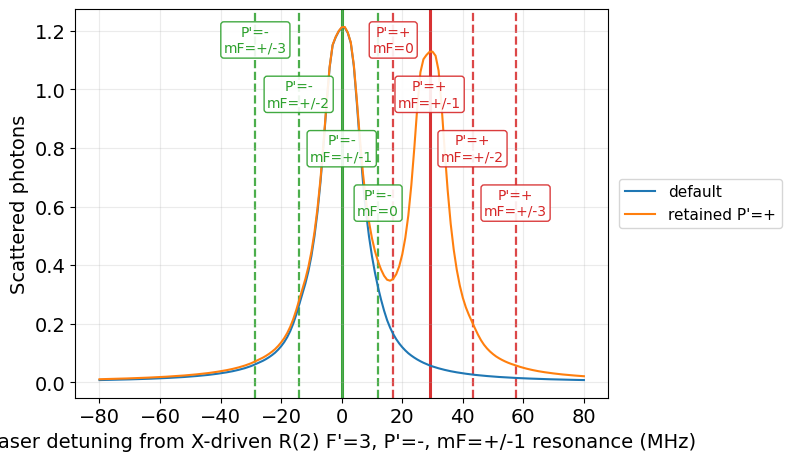

In [7]:
fig, ax = plt.subplots(figsize=(7.8, 4.5), constrained_layout=True)

for name, scan in frequency_scans.items():
    ax.plot(scan["detuning_MHz"], scan["photons"], label=DISPLAY_LABELS[name])

add_f3_level_markers(ax, max_abs_mhz=80.0)

ax.set_xlabel("Laser detuning from X-driven R(2) F'=3, P'=-, mF=+/-1 resonance (MHz)")
ax.set_ylabel("Scattered photons")
side_legend(ax)
ax.grid(alpha=0.25)


## Doppler averaging by convolution

The transverse velocity only shifts the effective laser detuning, so the Doppler-averaged photon curve is computed as a Gaussian convolution of a fine zero-transverse-velocity frequency scan. The solved range is padded beyond the visible `-80..80 MHz` range by several Doppler widths to keep edge effects outside the plotted window.


In [8]:
CONV_PLOT_LIMITS_MHZ = (-80.0, 80.0)
CONV_DETUNING_STEP_MHZ = 0.25
CONV_EDGE_PADDING_SIGMA = 8.0

conv_scan_min_mhz = CONV_PLOT_LIMITS_MHZ[0] - CONV_EDGE_PADDING_SIGMA * DOPPLER_SIGMA_MHZ
conv_scan_max_mhz = CONV_PLOT_LIMITS_MHZ[1] + CONV_EDGE_PADDING_SIGMA * DOPPLER_SIGMA_MHZ
DETUNING_SCAN_MHZ_CONV_FINE = np.arange(
    conv_scan_min_mhz,
    conv_scan_max_mhz + 0.5 * CONV_DETUNING_STEP_MHZ,
    CONV_DETUNING_STEP_MHZ,
)

convolution_scan_config = {
    "plot_limits_MHz": CONV_PLOT_LIMITS_MHZ,
    "solved_detuning_range_MHz": [
        float(DETUNING_SCAN_MHZ_CONV_FINE[0]),
        float(DETUNING_SCAN_MHZ_CONV_FINE[-1]),
    ],
    "detuning_step_MHz": CONV_DETUNING_STEP_MHZ,
    "solved_points": int(DETUNING_SCAN_MHZ_CONV_FINE.size),
    "total_system_solves": int(DETUNING_SCAN_MHZ_CONV_FINE.size * len(systems)),
    "doppler_sigma_MHz": float(DOPPLER_SIGMA_MHZ),
    "edge_padding_sigma": CONV_EDGE_PADDING_SIGMA,
}
convolution_scan_config


{'plot_limits_MHz': (-80.0, 80.0),
 'solved_detuning_range_MHz': [-121.09509652841234, 121.15490347158766],
 'detuning_step_MHz': 0.25,
 'solved_points': 970,
 'total_system_solves': 1940,
 'doppler_sigma_MHz': 5.136887066051542,
 'edge_padding_sigma': 8.0}

In [9]:
def gaussian_convolve_uniform_grid(
    x: np.ndarray,
    y: np.ndarray,
    sigma: float,
    truncate_sigma: float = 6.0,
) -> np.ndarray:
    dx = float(np.mean(np.diff(x)))
    if not np.allclose(np.diff(x), dx):
        raise ValueError("x must be uniformly spaced for convolution")

    half_width = int(np.ceil(truncate_sigma * sigma / dx))
    offsets = dx * np.arange(-half_width, half_width + 1)
    kernel = np.exp(-0.5 * (offsets / sigma) ** 2)
    kernel /= kernel.sum()

    return np.convolve(y, kernel, mode="same")


convolution_zero_velocity_scans = {
    name: photon_count_frequency_scan(
        system,
        detuning_mhz=DETUNING_SCAN_MHZ_CONV_FINE,
    )
    for name, system in systems.items()
}

convolution_doppler_scans = {
    name: {
        "detuning_MHz": scan["detuning_MHz"],
        "photons": gaussian_convolve_uniform_grid(
            scan["detuning_MHz"],
            scan["photons"],
            DOPPLER_SIGMA_MHZ,
        ),
        "zero_velocity_photons": scan["photons"],
        "zero_velocity_result": scan["result"],
    }
    for name, scan in convolution_zero_velocity_scans.items()
}

visible_conv = (DETUNING_SCAN_MHZ_CONV_FINE >= CONV_PLOT_LIMITS_MHZ[0]) & (
    DETUNING_SCAN_MHZ_CONV_FINE <= CONV_PLOT_LIMITS_MHZ[1]
)
convolution_scan_summary = {}
for name, scan in convolution_doppler_scans.items():
    visible_photons = scan["photons"][visible_conv]
    visible_detunings = scan["detuning_MHz"][visible_conv]
    peak_idx = int(np.argmax(visible_photons))
    convolution_scan_summary[name] = {
        "peak_detuning_MHz": float(visible_detunings[peak_idx]),
        "peak_photons": float(visible_photons[peak_idx]),
        "solver_total_seconds": scan["zero_velocity_result"].solver_stats.get("total_seconds")
        if scan["zero_velocity_result"].solver_stats is not None
        else None,
    }
print_scan_timings(convolution_scan_summary, "Convolution scan solver time")
convolution_scan_summary


Convolution scan solver time
  default: 1069.8 s
  retained P'=+: 1862.2 s


{'default': {'peak_detuning_MHz': -0.09509652841234129,
  'peak_photons': 0.9877669761281526,
  'solver_total_seconds': 1069.8312327000021},
 'retained_B_opposite_parity': {'peak_detuning_MHz': 0.15490347158765871,
  'peak_photons': 0.9975624457306166,
  'solver_total_seconds': 1862.1675820999953}}

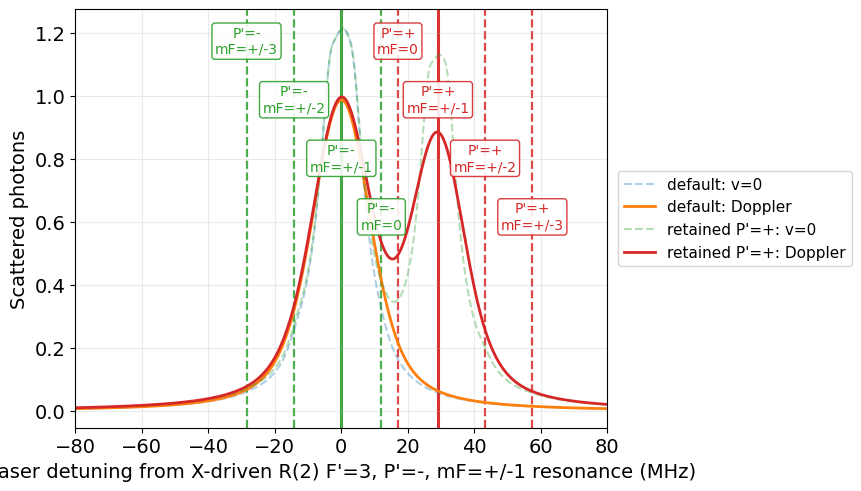

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)

for name, scan in convolution_doppler_scans.items():
    x = scan["detuning_MHz"][visible_conv]
    ax.plot(
        x,
        scan["zero_velocity_photons"][visible_conv],
        "--",
        alpha=0.35,
        label=f"{DISPLAY_LABELS[name]}: v=0",
    )
    ax.plot(
        x,
        scan["photons"][visible_conv],
        lw=2,
        label=f"{DISPLAY_LABELS[name]}: Doppler",
    )

add_f3_level_markers(ax, max_abs_mhz=80.0)

ax.set_xlim(*CONV_PLOT_LIMITS_MHZ)
ax.set_xlabel("Laser detuning from X-driven R(2) F'=3, P'=-, mF=+/-1 resonance (MHz)")
ax.set_ylabel("Scattered photons")
ax.grid(alpha=0.25)
side_legend(ax)


## Notes

- The default builder remains backwards compatible because the additional levels are not retained unless `retain_opposite_parity_levels=True`.
- For this R(2) transition at `200 V/cm`, retaining opposite parity adds the full nearby `F'=3, P'=+` mF ladder, not just one `mF=0` state.
- The convolution scan still uses the Rust parallel grid path through `photon_count_frequency_scan`; the Python loop over the two systems runs the default and retained scans sequentially.
- If the fine scan is too slow, first set `SCAN_THREADS` to a fixed core count or increase `CONV_DETUNING_STEP_MHZ`.
